# Gambling : Gagné à la Roulette sans perte, c'est possible ?  

Nous savons tous qu'au jeu de la roulette, il n’y a qu’un seul vrai gagnant c'est le casino. 

Le but de ce notebook est de simuler un jeu de roulette avec une stratégie permettant au joueur de maximiser ses chances de gain, ou au moins de limiter ses pertes.

Pour cela, nous allons simuler une martingale avec une méthode de Monte Carlo, et nous allons essayer de trouver les paramètres qui permettent de perdre le moins d’argent possible (et peut‑être même d’en gagner, si c’est possible !)

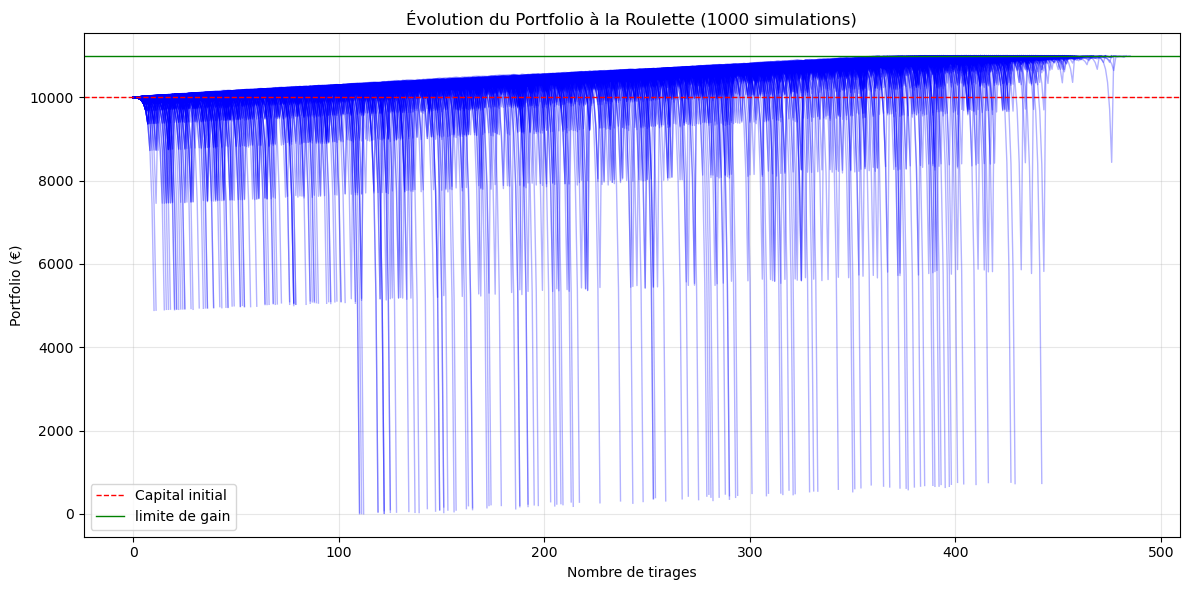

 Résultats après 1000 simulation :
  Capital moyen final: 9427.29 €
  Capital médian: 11000.00 €
  % de gain (>capital initial): 82.00%
  % de victoire (portfolio >= +10% de la mise initiale): 82.00%
  % de perte  (<capital initial): 18.00%
  Le max: 11000.00 €


In [ ]:
import random
import matplotlib.pyplot as plt 
import numpy as np


portfolio_depart = 10000
nb_tirage = 1000
mise_initial = 5

def roulette(mise_initial=mise_initial, portfolio_depart=portfolio_depart, nb_tirage = nb_tirage):        
    portfolio = portfolio_depart
    mise = mise_initial  
    historique = [portfolio]
    partie_win = 0  
    
    for i in range(nb_tirage): 
        
        tirage = random.randint(0,37)
        
        if tirage % 2 == 0 and tirage not in [0,37]:
            win = mise 
            portfolio += win
            couleur = "noir"
            mise = mise_initial
            #print(f"c'est {couleur} tu win {win} €, tu as mainteant {portfolio} €")

        elif (tirage+1) % 2 == 0 and tirage not in [0,37] : 
            loose = mise
            portfolio -= loose
            couleur = "rouge"
            mise = mise * 2 
            #print(f"c'est {couleur} tu lose {loose}€, tu as maintenant {portfolio}€")
            
        elif tirage == 0 or tirage == 37:
            loose = mise
            portfolio -= loose
            couleur = "vert"    
            mise = mise * 2      
            #print(f"c'est {couleur} (zéro) tu lose {loose} €, tu as maintenant {portfolio}€")
        
        historique.append(portfolio) 
  
        if portfolio <= 0 or portfolio < mise : 
            #print ("t'es encore ruiné :'(   ")
            break 
        if portfolio >= portfolio_depart * 1.1: # si le joueur a gagné 10% de son capital initial, il stop la partie
            #print(f"t'as gagné {portfolio} €, tu au {nb_tirage} tirages")
            partie_win = 1  
            break 
    
    return portfolio, historique, partie_win

resultats = [] # liste pour stocker les résultats de chaque simulation
simul = [] # liste pour stocker les historiques de chaque simulation
victoires = []  # Liste pour stocker les victoires (portfolio >= +10%)
nb_simul = 1000
for i in range(nb_simul):
    portfolio, historique, partie_win = roulette(mise_initial=mise_initial, portfolio_depart=portfolio_depart, nb_tirage = nb_tirage)
    resultats.append(portfolio)
    simul.append(historique)
    victoires.append(partie_win)    


# Graphique
plt.figure(figsize=(12, 6))
for hist in simul:
    plt.plot(hist, linewidth=1, color='blue', alpha=0.3)    
plt.axhline(y=portfolio_depart, color='red', linestyle='--', linewidth=1, label='Capital initial')
plt.axhline(y=1.1 * portfolio_depart, color='green', linestyle='-', linewidth=1, label='limite de gain')
plt.xlabel('Nombre de tirages')
plt.ylabel('Portfolio (€)')
plt.title(f'Évolution du Portfolio à la Roulette ({len(simul)} simulations)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Stats
resultats = np.array(resultats)
victoires = np.array(victoires)
print(f" Résultats après {len(simul)} simulation :")
print(f"  Capital moyen final: {resultats.mean():.2f} €")
print(f"  Capital médian: {np.median(resultats):.2f} €")
print(f"  % de gain (>capital initial): {(resultats > portfolio_depart).sum() / len(resultats) * 100:.2f}%")
print(f"  % de victoire (portfolio >= +10% de la mise initiale): {victoires.sum() / len(victoires) * 100:.2f}%")
print(f"  % de perte  (<capital initial): {(resultats < portfolio_depart).sum() / len(resultats) * 100:.2f}%")




Dans 82% des cas, on parvient à faire +10%, mais au final, malgré cela, le capital moyen final est inférieur au capital initial.

Autrement dit, même si l’on ne perd que dans 18% des cas,les pertes sont tellement lourde que nous sommes pas rentable en moyenne. 


# Monte-carlo optimisation 
 
pour pousser a bout mon pc faisons un peu de finance avec Vector bt. Nous allons tenter d'optimisé l'inoptimisable en modulant les combinaison de 3 facteurs , le portefeuille initial, la mise initial dans la martingale et le nombre de tirage de la roulette dans une seul partie  ( nb_tirage_test, mises_test, portfolios_test)

In [5]:
import vectorbt as vbt
import pandas as pd

# Paramètres à tester
portfolios_test = [1000, 50000, 100000, 1000000]
mises_test = [1,  10, 20]
nb_tirage_test=[10000]
# Résultats pour chaque combinaison
resultats_vbt = []

print(" Test des paramètres avec VectorBT...")

for portfolio_init in portfolios_test:
    for mise_init in mises_test:
        for nb_tirage_init in nb_tirage_test : 
            simulations = []
            portfolio_finaux = []
            for i in range(1000):
                portfolio_final, historique, partie_win = roulette(mise_initial=mise_init, portfolio_depart=portfolio_init, nb_tirage=nb_tirage_init)
                simulations.append(historique)
                portfolio_finaux.append(portfolio_final)


        # Calculer des stats
            capital_finaux = np.array(portfolio_finaux) 
            proba_gain = (capital_finaux > portfolio_init).sum() / len(capital_finaux) * 100
            return_moyen = ((capital_finaux.mean() - portfolio_init) / portfolio_init) * 100
            max_capital = capital_finaux.max()
            min_capital = capital_finaux.min()
            all_returns = []
        
        # Calculer les rendements périodiques pour chaque simulation

            for hist in simulations:   
                hist_array = np.array(hist)
                returns = (hist_array[1:] / hist_array[:-1]) - 1  # Rendement de chaque période
                all_returns.extend(returns)

            ecart_type = np.std(all_returns) * 100  # En %
            rendement_moyen_periodique = np.mean(all_returns) * 100  # En %
            # Ratio de Sharpe (rendement / volatilité)
            # Pour la roulette, pas de taux sans risque donc on utilise juste rendement/volatilité
            if ecart_type > 0:
                sharpe_ratio = rendement_moyen_periodique / ecart_type
            else:
                sharpe_ratio = 0
            
            resultats_vbt.append({
                'Portfolio Initial': portfolio_init,
                'Mise Initiale': mise_init,
                'nb_tirage': nb_tirage_init,
                'Capital Final Moyen': capital_finaux.mean(),
                'Return Moyen (%)': return_moyen,
                'Écart-Type (%)': ecart_type,
                'Sharpe Ratio': sharpe_ratio,
                'Capital Max': max_capital,
                'capital Min': min_capital,
                '% Gain': proba_gain,
                'Return Max (%)': ((max_capital - portfolio_init) / portfolio_init) * 100, 
                'return Min (%)': ((min_capital - portfolio_init) / portfolio_init) * 100
            })


df_resultats = pd.DataFrame(resultats_vbt)

print("   RÉSULTATS PAR PARAMÈTRES:\n")
print(df_resultats.to_string(index=False))

# Trouver la meilleure combinaison
best_return = df_resultats.loc[df_resultats['Return Moyen (%)'].idxmax()]
worst_return = df_resultats.loc[df_resultats['Return Moyen (%)'].idxmin()]
best_winrate = df_resultats.loc[df_resultats['% Gain'].idxmax()]
best_sharpe = df_resultats.loc[df_resultats['Sharpe Ratio'].idxmax()]


print(f"\n PIRE COMBINAISON (Return Moyen):")
print(f"   Portfolio: {worst_return['Portfolio Initial']:.0f}€ | Mise: {worst_return['Mise Initiale']:.0f}€ | Nb Tirages: {worst_return['nb_tirage']:.0f}")
print(f"   Return Moyen: {worst_return['Return Moyen (%)']:.2f}% | % Gain: {worst_return['% Gain']:.1f}%")
print(f"   Sharpe Ratio: {worst_return['Sharpe Ratio']:.3f} | Volatilité: {worst_return['Écart-Type (%)']:.2f}%")

print(f"\n MEILLEURE COMBINAISON (Sharpe Ratio - Meilleur Risk/Reward):")
print(f"   Portfolio: {best_sharpe['Portfolio Initial']:.0f}€ | Mise: {best_sharpe['Mise Initiale']:.0f}€ | Nb Tirages: {best_sharpe['nb_tirage']:.0f}")
print(f"   Sharpe Ratio: {best_sharpe['Sharpe Ratio']:.3f}")
print(f"   Return Moyen: {best_sharpe['Return Moyen (%)']:.2f}% | Volatilité: {best_sharpe['Écart-Type (%)']:.2f}%")
print(f"   % Gain: {best_sharpe['% Gain']:.1f}%")




 Test des paramètres avec VectorBT...
   RÉSULTATS PAR PARAMÈTRES:

 Portfolio Initial  Mise Initiale  nb_tirage  Capital Final Moyen  Return Moyen (%)  Écart-Type (%)  Sharpe Ratio  Capital Max  capital Min  % Gain  Return Max (%)  return Min (%)
              1000              1      10000              965.729         -3.427100        3.644586     -0.004324         1100            0    84.8         10.0000       -100.0000
              1000             10      10000              969.550         -3.045000        7.676668     -0.021009         1100          370    80.9         10.0000        -63.0000
              1000             20      10000              980.280         -1.972000       10.460693     -0.021182         1100          380    82.5         10.0000        -62.0000
             50000              1      10000            45099.609         -9.800782        0.437741     -0.002728        54884        17257    72.7          9.7680        -65.4860
             50000             1

 On vois les que les meilleurs combinaison sont celles avec un ratio portefeuille_initial/mise_initial le plus grand possible. On voit aussi que le nombre de tirages a un impact direct sur

In [6]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. HEATMAP : le return en fonction du portefeuille init , de la mise init et du nb de tirage
fig_heatmap = make_subplots(
    rows=1, cols=len(nb_tirage_test),
    subplot_titles=[f'Return Moyen (%) - {nb} tirages' for nb in nb_tirage_test],
    horizontal_spacing=0.1
)

for idx, nb_tirage in enumerate(nb_tirage_test):
    df_subset = df_resultats[df_resultats['nb_tirage'] == nb_tirage]
    
    # Créer la du return  matrice Portfolio x Mise
    pivot_data = df_subset.pivot_table(
        values='Return Moyen (%)',
        index='Portfolio Initial',
        columns='Mise Initiale',
        aggfunc='mean'
    )
    
    # fabrique de la heatmap
    fig_heatmap.add_trace(
        go.Heatmap(
            z=pivot_data.values,
            x=pivot_data.columns,
            y=pivot_data.index,  
            hovertemplate='Portfolio: %{y:,.0f}€<br>Mise: %{x}€<br>Return: %{z:.2f}%<extra></extra>',
            colorscale='RdYlGn',
            text=pivot_data.values,
            texttemplate='%{text:.1f}%',
            textfont={"size": 10},
            colorbar=dict[str, str | float](title="Return (%)", x=1.02 + idx*0.3) if idx == len(nb_tirage_test)-1 else None,
            showscale=(idx == len(nb_tirage_test)-1)
        ),
        row=1, col=idx+1
    )
    
    fig_heatmap.update_xaxes(title_text="Mise Initiale (€)", row=1, col=idx+1)
    
    # Configurer l'axe Y en échelle logarithmique pour voir la heatmap correctment 
    portfolio_values = sorted(pivot_data.index)
    fig_heatmap.update_yaxes(
        title_text="Portfolio Initial(€)",
        type="log",
        row=1, col=idx+1,
        tickmode='array',
        tickvals=portfolio_values,  
        ticktext=[f'{val:,.0f}' if val < 1000 else f'{val/1000:.0f}K' if val < 1000000 else f'{val/1000000:.1f}M' 
                 for val in portfolio_values]  
    )

fig_heatmap.update_layout(
    height=400,
    width=1400,
    title_text="Heatmap du Return Moyen en (%)"
)
fig_heatmap.show()



## BLACK JACK GAMBLING 

Comme je suis joueur et qu'il faut que je m'entraine à la programation orianté objet on va tenter de faire de meme pour le jeu du black jack.  

On commence par fabriqué le moteur de jeu : 

In [23]:


#fabrique un jeu de 52 Carte et associe chaque carte a une valeur 
def packer():
    ranks = ['2', '3', '4', '5', '6', '7', '8','9', '10', 'J', 'Q', 'K', 'A']
    suits = ['♠', '♥', '♦', '♣']
    card_value = 0 
    main = 11  
    rank_values = {}
    for rank in ranks:
        if rank in ['J', 'Q', 'K']: 
            card_value = 10
        elif rank == 'A':  # l'as peu prendre 2 valeurs selon ce qu'on a dans la main. 
            if main <= 10  : 
                card_value = 11
            else:
                card_value = 1 
        else : 
            card_value = int(rank)        
        #print(f"{card_value} pour {rank} ")         
        rank_values[rank] = card_value
    
    deck = [(rank, suit, rank_values[rank]) for rank in ranks for suit in suits]    

    print(deck)
    print(rank_values['9'])

packer()

def jeudecarte(nb_depacker = 6 ):


SyntaxError: incomplete input (1882662866.py, line 28)

['Australie', 'America']
